In [1]:
import numpy as np 
import pandas as pd
import seaborn as sns

from datasets import  load_dataset

d:\Emotion Detection\.Venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
emotion_dataset = load_dataset("csv", data_files={
    "train": "data/train.csv",
    "validation": "data/validation.csv",
    "test": "data/test.csv"
})


In [3]:





train_text = emotion_dataset['train']['text']

In [4]:
train_label = emotion_dataset['train']['label']

In [5]:
train_label

Column([0, 0, 3, 2, 3, ...])

In [6]:
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [7]:
# Replace:
# names = emotion_dataset['train'].features['label'].names

# With:
names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [8]:
from datasets import ClassLabel

class_labels = ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])
emotion_dataset = emotion_dataset.cast_column('label', class_labels)

names = emotion_dataset['train'].features['label'].names


In [9]:
df_train = pd.DataFrame({
    'text' : train_text,
    "label": [names[i] for i in train_label]

})

In [10]:
# Preview first 10 labels instead of printing all 16,000
for i in train_label[:10]:
    print(names[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love


In [11]:
# Preview first 10 labels instead of printing all 16,000
for i in train_label[:10]:
    print(names[i])

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love


In [12]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [13]:
df_test = pd.DataFrame({
    'text' : test_text,
    "label": [names[i] for i in test_label]

})

In [14]:
df_test

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness
...,...,...
1995,i just keep feeling like someone is being unki...,anger
1996,im feeling a little cranky negative after this...,anger
1997,i feel that i am useful to my people and that ...,joy
1998,im feeling more comfortable with derby i feel ...,joy


<Axes: xlabel='label', ylabel='count'>

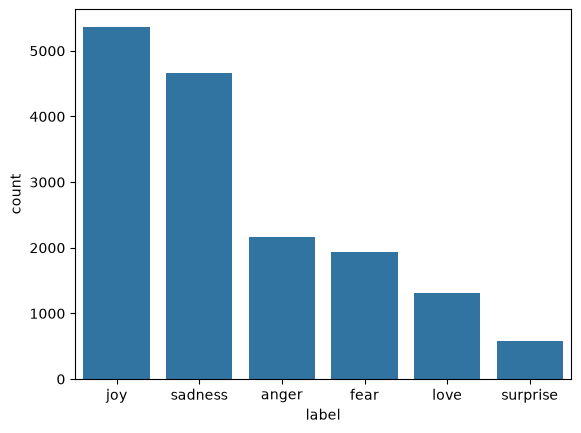

In [15]:
sns.countplot(x ='label',data=df_train, order =df_train['label'].value_counts().index)

## 1. Dataset Overview & Quality Checks
Checking dimensions, missing values, duplicates, and split consistency.

In [16]:
# Check dimensions and data integrity
print(f"Train samples: {len(df_train)}")
print(f"Test samples:  {len(df_test)}")
print(f"Missing values (Train): {df_train.isnull().sum().to_dict()}")
print(f"Duplicate texts (Train): {df_train['text'].duplicated().sum()}")

# Detailed label counts & percentages in Train
train_counts = df_train['label'].value_counts()
train_pcts = df_train['label'].value_counts(normalize=True) * 100
pd.DataFrame({'Count': train_counts, 'Percentage (%)': train_pcts.round(2)})

Train samples: 16000
Test samples:  2000
Missing values (Train): {'text': 0, 'label': 0}
Duplicate texts (Train): 31


,Count,Percentage (%)
label,,
joy,5362,33.51
sadness,4666,29.16
anger,2159,13.49
fear,1937,12.11
love,1304,8.15
surprise,572,3.58


## 2. Emotion Label Distribution & Class Imbalance Analysis
Visualizing class distribution across the 6 emotion categories.

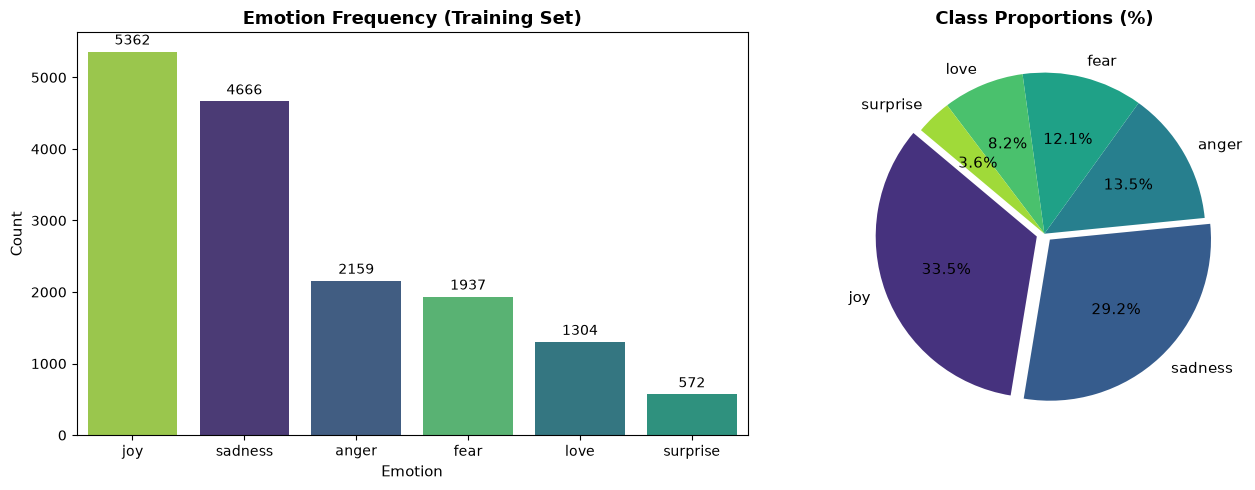

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Subplot 1: Bar Chart with Count Annotations
plt.subplot(1, 2, 1)
order = df_train['label'].value_counts().index
palette = sns.color_palette('viridis', len(order))
ax = sns.countplot(data=df_train, x='label', order=order, hue='label', legend=False, palette=palette)
plt.title('Emotion Frequency (Training Set)', fontsize=13, fontweight='bold')
plt.xlabel('Emotion', fontsize=11)
plt.ylabel('Count', fontsize=11)

for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{int(h)}', (p.get_x() + p.get_width() / 2., h),
                    ha='center', va='baseline', fontsize=10, xytext=(0, 5), textcoords='offset points')

# Subplot 2: Pie Chart
plt.subplot(1, 2, 2)
counts = df_train['label'].value_counts()
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', colors=palette, startangle=140,
        explode=[0.05 if i < 2 else 0 for i in range(len(counts))], textprops={'fontsize': 11})
plt.title('Class Proportions (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Text Length & Sequence Length Analysis
Analyzing sentence word counts and character counts to determine the optimal transformer `max_length`.

--- Word Count Summary (Percentiles) ---
count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
90%         35.000000
95%         41.000000
99%         52.000000
max         66.000000
Name: word_count, dtype: float64


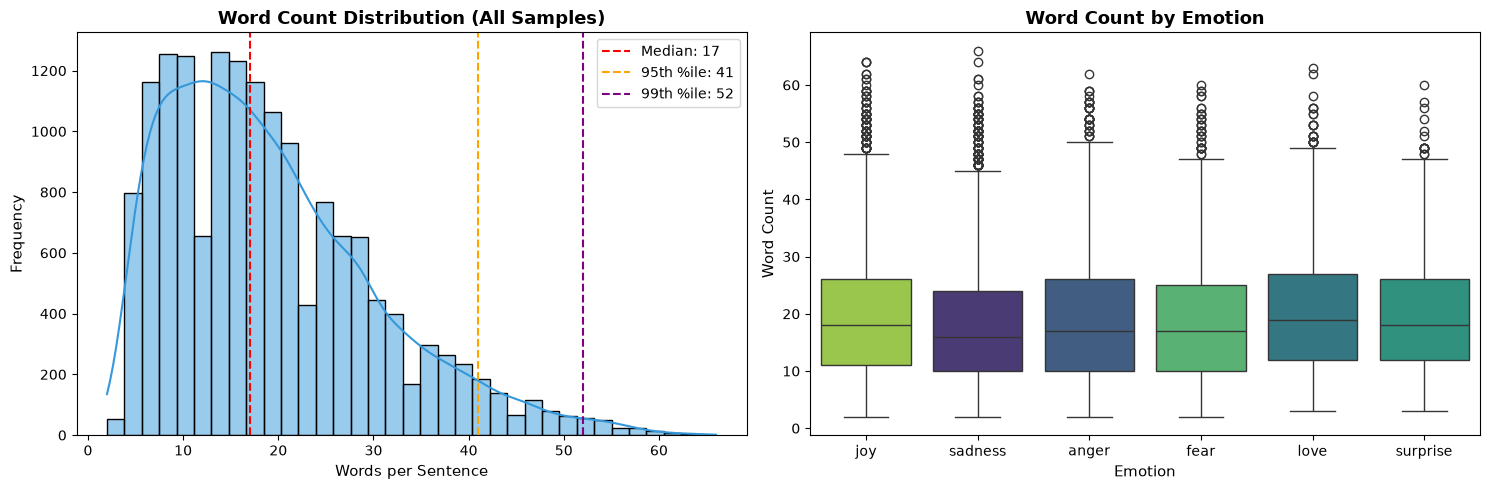

In [18]:
# Add character and word count features
df_train['char_count'] = df_train['text'].apply(len)
df_train['word_count'] = df_train['text'].apply(lambda x: len(x.split()))

print("--- Word Count Summary (Percentiles) ---")
print(df_train['word_count'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]))

plt.figure(figsize=(15, 5))

# Subplot 1: Overall word count distribution
plt.subplot(1, 2, 1)
sns.histplot(data=df_train, x='word_count', kde=True, bins=35, color='#3498db')
plt.axvline(df_train['word_count'].median(), color='red', linestyle='--', label=f'Median: {df_train["word_count"].median():.0f}')
plt.axvline(df_train['word_count'].quantile(0.95), color='orange', linestyle='--', label=f'95th %ile: {df_train["word_count"].quantile(0.95):.0f}')
plt.axvline(df_train['word_count'].quantile(0.99), color='purple', linestyle='--', label=f'99th %ile: {df_train["word_count"].quantile(0.99):.0f}')
plt.title('Word Count Distribution (All Samples)', fontsize=13, fontweight='bold')
plt.xlabel('Words per Sentence', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.legend()

# Subplot 2: Word counts by emotion
plt.subplot(1, 2, 2)
sns.boxplot(data=df_train, x='label', y='word_count', order=order, hue='label', legend=False, palette=palette)
plt.title('Word Count by Emotion', fontsize=13, fontweight='bold')
plt.xlabel('Emotion', fontsize=11)
plt.ylabel('Word Count', fontsize=11)

plt.tight_layout()
plt.show()

In [19]:

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000
tokenizer = Tokenizer(num_words =max_words, oov_token = "<unk>")

tokenizer.fit_on_texts(df_train['text'])
train_sequence = tokenizer.texts_to_sequences(df_train['text'])


In [20]:
test_sequence = tokenizer.texts_to_sequences(df_test['text'])


In [21]:
train_sequence

[[2, 139, 3, 679],
 [2,
  40,
  101,
  60,
  8,
  15,
  494,
  5,
  15,
  3496,
  553,
  32,
  60,
  61,
  128,
  148,
  76,
  1480,
  4,
  22,
  1255],
 [17, 3060, 7, 1149, 5, 286, 2, 3, 495, 438],
 [2, 24, 165, 8, 665, 27, 6, 4158, 2, 59, 47, 9, 13, 22, 72, 30, 6, 3497],
 [2, 24, 8, 1065],
 [73, 48, 8, 7, 56, 521, 319, 328, 158, 161, 9, 20],
 [73,
  48,
  329,
  35,
  7401,
  35,
  196,
  7402,
  888,
  4,
  73,
  2475,
  1384,
  7,
  159,
  1885,
  19,
  2,
  117,
  3,
  14,
  15,
  455],
 [2, 3, 29, 439, 27, 78, 29, 7, 1686, 35, 29, 760, 29, 7, 193, 267, 374],
 [2,
  21,
  48,
  25,
  5260,
  16,
  215,
  2,
  3,
  9,
  5260,
  99,
  5261,
  135,
  4,
  132,
  7,
  1038,
  4159],
 [2, 3, 666, 94],
 [2, 3, 14, 2, 21, 5, 80, 6, 733, 2, 93, 544, 304, 84],
 [2,
  39,
  3,
  9,
  483,
  22,
  7,
  530,
  440,
  4,
  9,
  2,
  40,
  920,
  5,
  21,
  69,
  840,
  10,
  1886,
  3061],
 [2, 70, 13, 90, 6, 5262, 52, 10, 193, 5, 3, 610],
 [2, 3, 339, 456, 2, 93, 32, 4160],
 [2,
  21,
  4161,

In [22]:
padded_train_sequence = pad_sequences(train_sequence, padding = 'post', maxlen=50, truncating= 'post')

In [23]:
padded_test_sequence = pad_sequences(test_sequence, padding = 'post', maxlen=50, truncating= 'post')

In [24]:
padded_train_sequence[0]

array([  2, 139,   3, 679,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0], dtype=int32)

In [25]:
train_label = np.array(train_label)

In [26]:
test_label = np.array(test_label)

In [27]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight= "balanced",
    classes=np.unique(train_label),
    y = train_label
)
dict(enumerate(class_weights))

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

## 3. Build and Train RNN and LSTM Models

In [29]:
class_weights_dict = dict(enumerate(class_weights))
class_weights_dict

{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dense, Dropout

# Model 1: Simple RNN
rnn_model = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=max_words, output_dim=128),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
  
    SimpleRNN(units=68, return_sequences=False),
    Dropout(0.5),
  
    Dense(6, activation='softmax')
])

rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 50, 128)        │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,346,566 (5.14 MB)

 Trainable params: 1,346,566 (5.14 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Ensure early_stopping is available
from tensorflow.keras.callbacks import EarlyStopping
if 'early_stopping' not in locals():
    early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train Simple RNN
rnn_history = rnn_model.fit(
    padded_train_sequence, train_label,
    epochs=50,
    validation_data=(padded_test_sequence, test_label),
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1579 - loss: 1.9347 - val_accuracy: 0.1430 - val_loss: 1.7893
Epoch 2/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1554 - loss: 1.8541 - val_accuracy: 0.2445 - val_loss: 1.7604
Epoch 3/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1469 - loss: 1.8605 - val_accuracy: 0.0330 - val_loss: 1.8696
Epoch 4/50
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.1347 - loss: 1.8311 - val_accuracy: 0.0540 - val_loss: 1.7703


In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout

# Model 2: LSTM
lstm_model = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=10000, output_dim=128),
    LSTM(128, return_sequences=False),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,420,230 (5.42 MB)

 Trainable params: 1,420,230 (5.42 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# Ensure early_stopping is available
from tensorflow.keras.callbacks import EarlyStopping
if 'early_stopping' not in locals():
    early_stopping = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Train LSTM
lstm_history = lstm_model.fit(
    padded_train_sequence, train_label,
    epochs=5,
    validation_data=(padded_test_sequence, test_label),
    class_weight=class_weights_dict,
    callbacks=[early_stopping]
)

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.1397 - loss: 1.7938 - val_accuracy: 0.1375 - val_loss: 1.7943
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.1211 - loss: 1.7928 - val_accuracy: 0.1145 - val_loss: 1.8008
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.1542 - loss: 1.7919 - val_accuracy: 0.0405 - val_loss: 1.8027


In [34]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D, SpatialDropout1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. High-Performance Bidirectional LSTM Model
bilstm_model = Sequential([
    Input(shape=(50,)),
    Embedding(input_dim=10000, output_dim=128),
    SpatialDropout1D(0.2),                                  # Regularize embedding features
    Bidirectional(LSTM(64, return_sequences=True)),        # Reads forward and backward
    GlobalMaxPooling1D(),                                  # Extracts peak emotional words
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(6, activation='softmax')
])

bilstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

bilstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 50, 128)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 50, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 50, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,387,462 (5.29 MB)

 Trainable params: 1,387,462 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [35]:
# 2. Callbacks for optimal convergence
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=1, min_lr=1e-5, verbose=1)
]

# 3. Train (Notice: no class_weight needed for fast convergence)
history = bilstm_model.fit(
    padded_train_sequence, train_label,
    epochs=10,
    batch_size=64,
    validation_data=(padded_test_sequence, test_label),
    callbacks=callbacks
)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.4724 - loss: 1.3413 - val_accuracy: 0.7885 - val_loss: 0.6596 - learning_rate: 0.0010
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8700 - loss: 0.3959 - val_accuracy: 0.9105 - val_loss: 0.2050 - learning_rate: 0.0010
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9418 - loss: 0.1597 - val_accuracy: 0.9200 - val_loss: 0.1961 - learning_rate: 0.0010
Epoch 4/10
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9602 - loss: 0.1067
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9600 - loss: 0.1070 - val_accuracy: 0.9170 - val_loss: 0.2009 - learning_rate: 0.0010
Epoch 5/10
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9760 - loss: 0.0688
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9762 - loss: 0.06

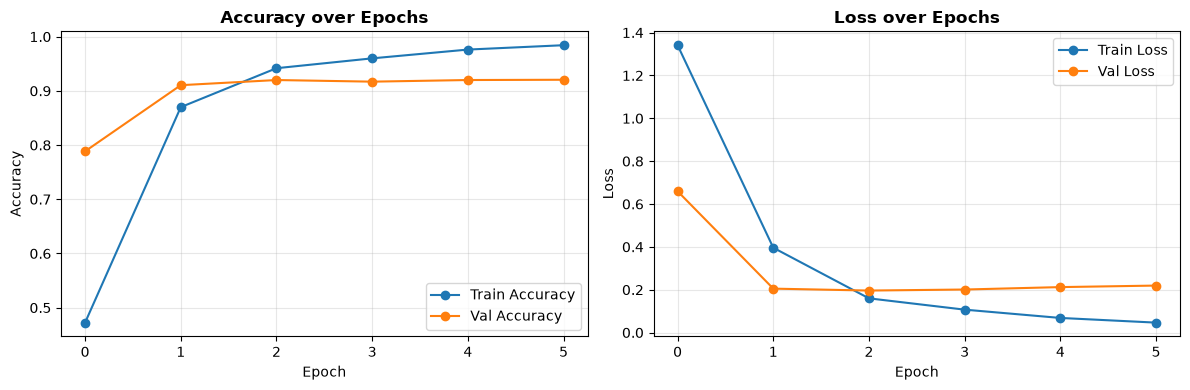

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Subplot 1: Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', marker='o')
plt.title('Accuracy over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Val Loss', marker='o')
plt.title('Loss over Epochs', fontsize=12, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
=== Classification Report ===
              precision    recall  f1-score   support

     sadness       0.94      0.97      0.96       581
         joy       0.95      0.94      0.94       695
        love       0.79      0.81      0.80       159
       anger       0.94      0.92      0.93       275
        fear       0.92      0.85      0.88       224
    surprise       0.75      0.76      0.75        66

    accuracy                           0.92      2000
   macro avg       0.88      0.87      0.88      2000
weighted avg       0.92      0.92      0.92      2000



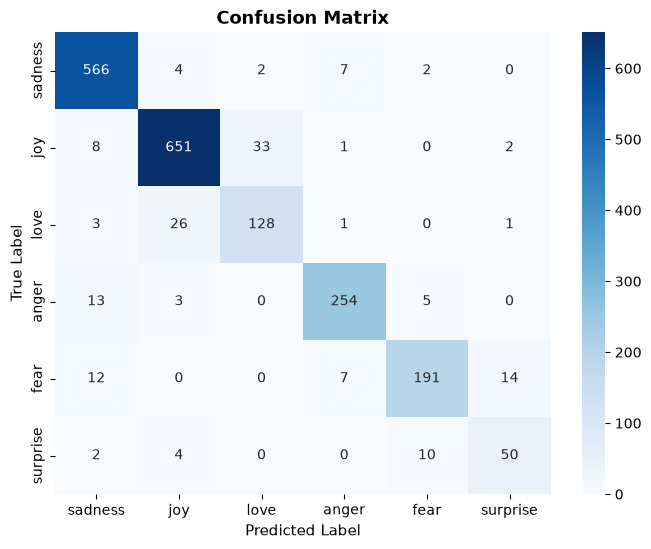

In [37]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Generate predictions on test data
y_pred_probs = bilstm_model.predict(padded_test_sequence)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. Detailed Classification Report (Precision, Recall, F1 per class)
print("=== Classification Report ===")
print(classification_report(test_label, y_pred, target_names=names))

# 3. Confusion Matrix Heatmap
cm = confusion_matrix(test_label, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=names, yticklabels=names)
plt.title('Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.show()


In [38]:
def predict_emotion(text):
    # Preprocess text
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=50, padding='pre', truncating='pre')
    
    # Predict probabilities
    probs = bilstm_model.predict(padded, verbose=0)[0]
    pred_idx = np.argmax(probs)
    pred_label = names[pred_idx]
    confidence = probs[pred_idx] * 100
    
    print(f"\nText: \"{text}\"")
    print(f"Predicted Emotion: {pred_label.upper()} ({confidence:.2f}% confidence)")
    print("\nAll Probabilities:")
    for name, prob in zip(names, probs):
        bar = "█" * int(prob * 30)
        print(f"  {name:9s} : {prob*100:5.2f}% {bar}")
    
    return pred_label

# Test samples
predict_emotion("I can't believe this happened, I'm absolutely thrilled and over the moon!")
predict_emotion("I feel like I'm sinking and nothing is going right today.")
predict_emotion("Why does this keep happening? It makes my blood boil!")



Text: "I can't believe this happened, I'm absolutely thrilled and over the moon!"
Predicted Emotion: JOY (94.92% confidence)

All Probabilities:
  sadness   :  0.27% 
  joy       : 94.92% ████████████████████████████
  love      :  1.80% 
  anger     :  0.45% 
  fear      :  0.79% 
  surprise  :  1.77% 

Text: "I feel like I'm sinking and nothing is going right today."
Predicted Emotion: JOY (29.04% confidence)

All Probabilities:
  sadness   : 21.13% ██████
  joy       : 29.04% ████████
  love      : 14.77% ████
  anger     : 12.59% ███
  fear      : 15.95% ████
  surprise  :  6.51% █

Text: "Why does this keep happening? It makes my blood boil!"
Predicted Emotion: LOVE (32.04% confidence)

All Probabilities:
  sadness   :  6.61% █
  joy       : 17.71% █████
  love      : 32.04% █████████
  anger     : 18.04% █████
  fear      : 12.50% ███
  surprise  : 13.11% ███


'love'

In [39]:
predict_emotion('Sometimes, the future feels like a dark road with no signs')


Text: "Sometimes, the future feels like a dark road with no signs"
Predicted Emotion: FEAR (78.62% confidence)

All Probabilities:
  sadness   :  0.66% 
  joy       :  1.93% 
  love      :  0.70% 
  anger     :  1.14% 
  fear      : 78.62% ███████████████████████
  surprise  : 16.97% █████


'fear'